# SENTINEL-WM | Phase 1 - Data Pre-processing

`data/unified_AllDays_labeled.csv` (all 5 CIC-IDS-2017 days, ~2.8 M flows,
15 attack families) -> `artifacts/clean_flows.parquet`.

* normalise the `Label` string -> `attack_family` -> `is_attack`
* replace CICFlowMeter `Infinity`/`NaN` rate cells, winsorise heavy tails
* derive `day` from `source_day` / `source_file`; `flow_start_epoch` = time axis
* keep IPs/ports for windowing only - never a model input (`config.IDENTITY_COLS`)

In [1]:
# bootstrap: make the sentinel_wm package importable without pip install
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root if (_root / 'sentinel_wm').is_dir() else _root.parent
if str(_root) not in sys.path: sys.path.insert(0, str(_root))

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sentinel_wm import config as C, preprocessing as P
pd.set_option('display.max_columns', 40)

## 1.1  Peek at the raw file

In [3]:
raw = pd.read_csv(C.RAW_FLOW_CSVS[0], nrows=200_000, low_memory=False)
print(raw.shape); raw['Label'].value_counts()

(200000, 127)


BENIGN    200000
Name: Label, dtype: int64

### Known CIC-IDS-2017 quirks the cleaner fixes
`Flow Bytes/s` / `Flow Packets/s` = `Infinity` on zero-duration flows;
boolean fragment flags; en-dash vs hyphen label spellings across days.

In [4]:
rate = raw[['Flow Bytes/s','Flow Packets/s']].replace([np.inf,-np.inf], np.nan)
print('non-finite rate cells in sample:', int(rate.isna().sum().sum()))

non-finite rate cells in sample: 358


## 1.2  Clean the whole corpus

In [5]:
flows = P.load_and_clean(verbose=True)
flows[['day','flow_start_epoch','attack_family','is_attack']].head()

[load] unified_AllDays_labeled.csv (2.37 GB)


  cleaned 2,829,609 -> 2,829,609 rows | 97 numeric model cols | 5,734 inf/NaN cells zero-filled
  family distribution:
BENIGN                      2271975
    DoS Hulk                     231073
    PortScan                     158927
    DDoS                         128027
    DoS GoldenEye                 10293
    FTP-Patator                    7938
    SSH-Patator                    5897
    DoS slowloris                  5794
    DoS Slowhttptest               5492
    Bot                            1966
    Web Attack Brute Force         1507
    Web Attack XSS                  652
    Infiltration                     36
    Web Attack SQL Injection         21
    Heartbleed                       11


[save] C:\Users\chall\OneDrive\Desktop\SIH\artifacts\clean_flows.parquet  (2,829,609 rows, 130 cols)
[days] ['Friday', 'Monday', 'Thursday', 'Tuesday', 'Wednesday']


,day,flow_start_epoch,attack_family,is_attack
0,Friday,1.499429e+09,BENIGN,0
1,Friday,1.499429e+09,BENIGN,0
2,Friday,1.499429e+09,BENIGN,0
3,Friday,1.499429e+09,BENIGN,0
4,Friday,1.499429e+09,BENIGN,0


## 1.3  Feature tiers (locked schema in `config.py`)

In [6]:
for name, cols in [('IDENTITY (not model input)', C.IDENTITY_COLS),
                   ('TIER 1 flow  (CSV)',          C.TIER1_FLOW_COLS),
                   ('TIER 2 packet (PCAP)',        C.TIER2_PACKET_COLS),
                   ('TIER 4 metadata (excluded)',  C.METADATA_COLS)]:
    have = [c for c in cols if c in flows.columns]
    print(f'{name:30s} {len(have):3d}  e.g. {have[:4]}')

IDENTITY (not model input)       7  e.g. ['Flow ID', 'Source IP', 'Destination IP', 'Source Port']
TIER 1 flow  (CSV)              63  e.g. ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets']
TIER 2 packet (PCAP)            26  e.g. ['pkt_ttl_mean', 'pkt_ttl_std', 'pkt_ttl_min', 'pkt_ttl_max']
TIER 4 metadata (excluded)      22  e.g. ['source_file', 'source_day', 'profile', 't_min']


## 1.4  Family distribution + per-day attack timeline

In [7]:
flows['attack_family'].value_counts()

BENIGN                      2271975
DoS Hulk                     231073
PortScan                     158927
DDoS                         128027
DoS GoldenEye                 10293
FTP-Patator                    7938
SSH-Patator                    5897
DoS slowloris                  5794
DoS Slowhttptest               5492
Bot                            1966
Web Attack Brute Force         1507
Web Attack XSS                  652
Infiltration                     36
Web Attack SQL Injection         21
Heartbleed                       11
Name: attack_family, dtype: int64

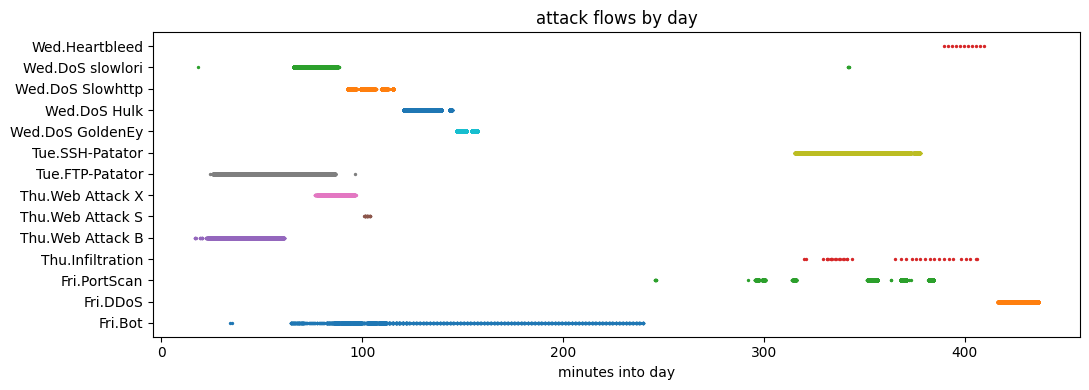

In [8]:
g = flows.copy()
g['min'] = g.groupby('day')['flow_start_epoch'].transform(lambda s:(s-s.min())/60)
fig,ax = plt.subplots(figsize=(11,4))
for day,sub in g[g.is_attack==1].groupby('day'):
    for fam,s2 in sub.groupby('attack_family'):
        ax.scatter(s2['min'], [f'{day[:3]}.{fam[:12]}']*len(s2), s=2)
ax.set_xlabel('minutes into day'); ax.set_title('attack flows by day'); plt.tight_layout()

Next: **`02_sequence_generation.ipynb`** - 10 s state windows, progression
states, MITRE ATT&CK mapping, leakage-safe split.